<a href="https://colab.research.google.com/github/mstyOps/ML-on-titanic-dataset/blob/main/Dt%20on%20titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
titanic = pd.read_csv('/content/titanic.csv')

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin',	'Embarked'], inplace = True)

In [ ]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0


In [ ]:
titanic.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0


In [ ]:
titanic['Age'] = titanic['Age'].fillna(value = titanic.groupby('Pclass')['Age'].transform('mean'))

In [ ]:
titanic['Sex'] = titanic['Sex'].map({'male' : 0, 'female' : 1})

In [ ]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,0,22.0,1,0
1,1,1,1,38.0,1,0
2,1,3,1,26.0,0,0
3,1,1,1,35.0,1,0
4,0,3,0,35.0,0,0


In [ ]:
X = titanic.drop(columns = ['Survived'])
Y = titanic['Survived']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify=Y)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, Y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
print('Accuracy:', accuracy_score(Y_test, y_pred))
print('Classification Report\n', classification_report(Y_test, y_pred))

Accuracy: 0.8044692737430168
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
dict = {'Variables' : X.columns, 'Information Gain' : dt.feature_importances_}
df = pd.DataFrame(dict)
df.sort_values(by = 'Information Gain', ascending = False)

,Variables,Information Gain
1,Sex,0.388562
2,Age,0.348304
0,Pclass,0.146620
3,SibSp,0.076265
4,Parch,0.040249


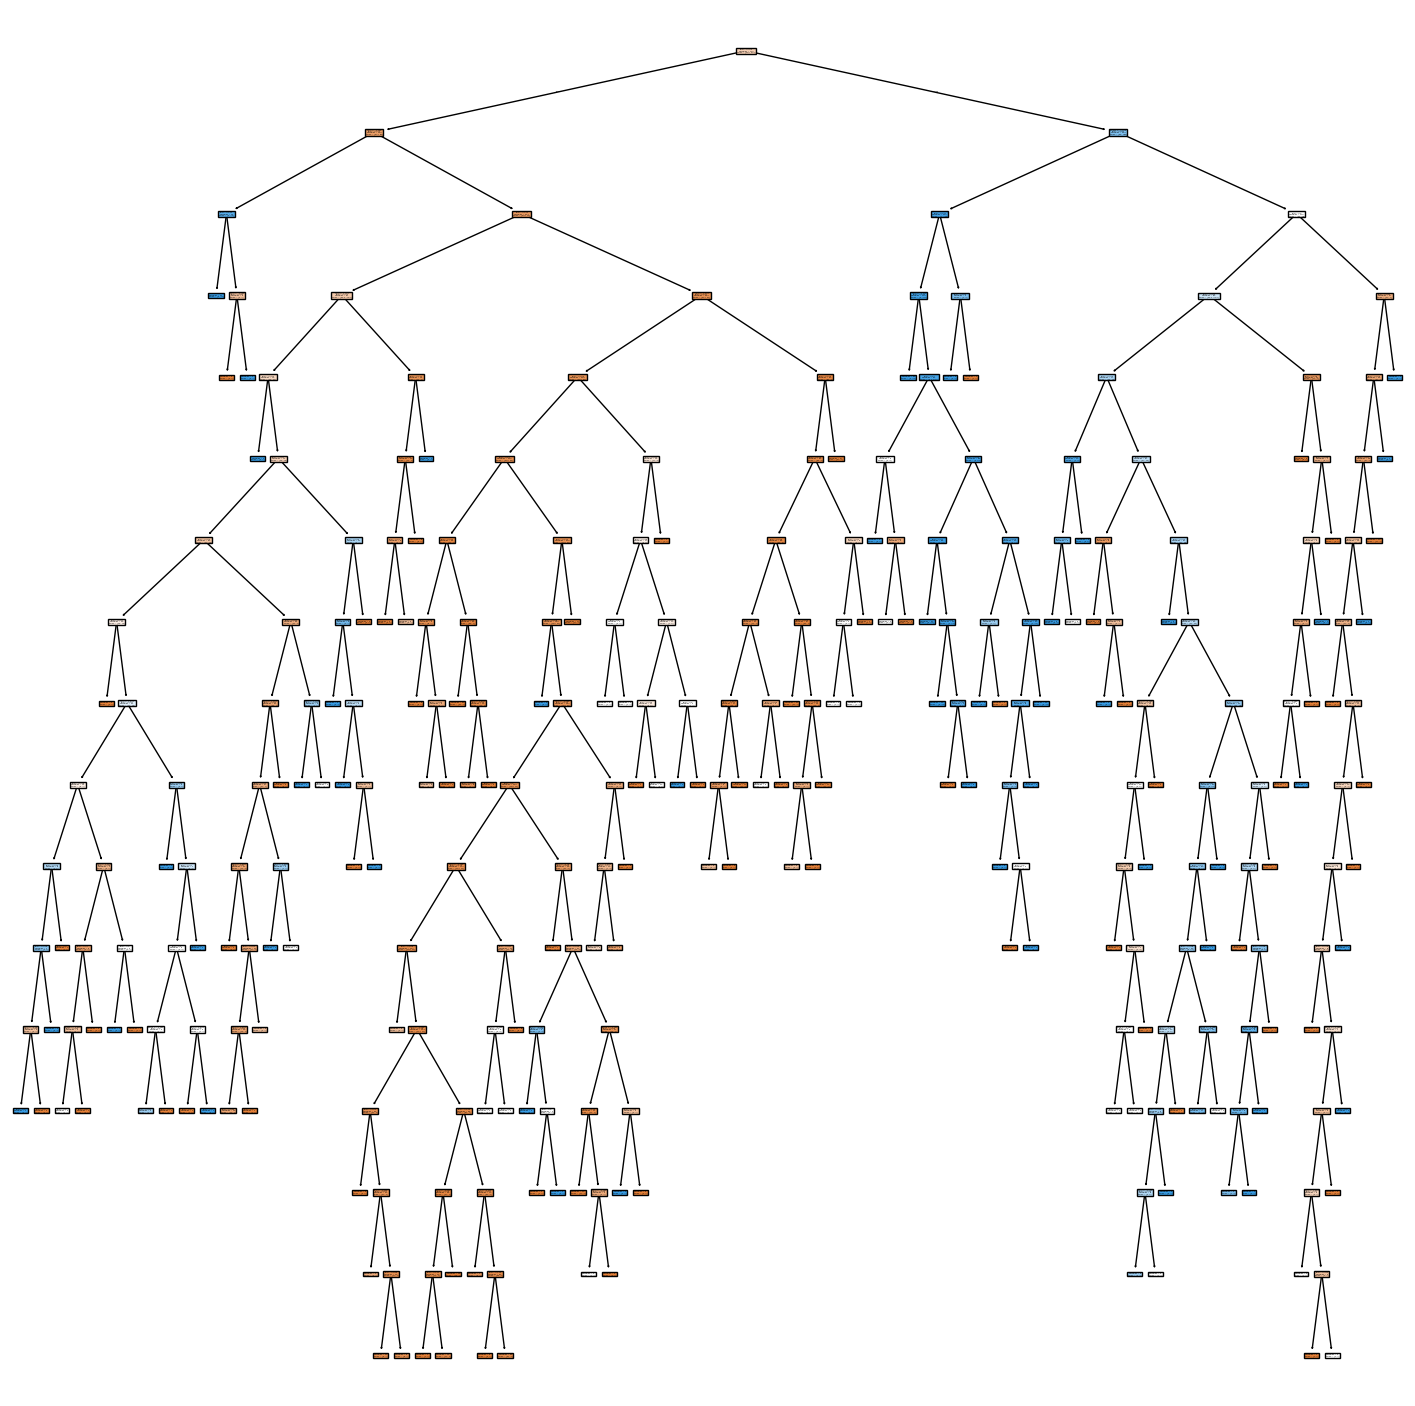

In [ ]:
from sklearn import tree
plt.figure(figsize=(18,18))
tree.plot_tree(dt, feature_names= X.columns, filled=True)
plt.show()